In [6]:
# -------------------------------------------------------------
# Data Sources and Analysis:
# -------------------------------------------------------------

In [5]:
# Data Source Possibility 1:
    # Brandon Sanderson - The Way of Kings
    # Brandon Sanderson - Elantris
# Type of Comparisons:
    # 1. How has Sanderson's writing style changed over the course of his career? Elantris was written when he first got into the business-
        # and "The Way of Kings" is the first book in his biggest Fantasy Epic.
    # 2. What words did Brandon use frequently as a novice writer versus a much more seasoned veteren?

# Data Source Possibility 2:
    # Brandon Sanderson - The Way of Kings
    # Robert Jordan - The Eye of the World
# Type of Comparisons:
    # 1. How do Brandon Sanderson's and Robert Jordan's writing style's differ? What words do they tend to frequently use in the start of their-
            # Fantasy Epics?
    # 2. Is Sanderson's descriptions longer than Jordan's or smaller?
    # 3. How many words or sentence structures do Sanderson and Jordan share between their Fantasy Epics?

# Chosen Possibility - Data Source 1
    # I would like to understand how Brandon Sanderson's writing style has changed over the years of his work.

# Goals:
    # 1. Figure out what words Sanderson used to use frequently, but no longer does.
    # 2. Figure out what words Sanderson usually frequently uses know, but didn't in the past.
    # 3. Try to figure out if Sanderson's sentence structure has changed over the years.
    # 4. Try to figure out if Sanderson's descriptions have become larger or shorter compared to his past work.

In [ ]:
# -------------------------------------------------------------
# Assignment 1.1:
# -------------------------------------------------------------

In [6]:
# Setup:

%pip install pymupdf nltk

import os
print('\n\n')
print(os.getcwd())              # shows the server folder your notebook is in
print(os.listdir("."))

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



/home/cdamron3/MiniProject1
['.git', 'MiniProject1.ipynb', 'README.md', 'pg4680.txt', '.ipynb_checkpoints', 'cdamron3.ipynb', 'Elantris_Brandon_S.pdf', 'WOK_Brandon_S.pdf']


In [2]:
import nltk, re
nltk.download('stopwords')
from collections import Counter
import operator
import pymupdf

# we may not care about the usage of stop words
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

def cleanPDF(path, start_page = 0, end_page = None):
    text= []
    with pymupdf.open(path) as pdf:
        if end_page == None:
            end_page = pdf.page_count - 1
        for i in range(start_page, end_page + 1):
            text.append(pdf[i].get_text())
    return "\n".join(text)

# We also want to remove special characters, quotes, etc. from each word
def cleanWord(w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub('[,"\.\'&\|:@>*;/=\u201c\u201d]', "", w)
    # get rid of numbers
    return re.sub('^[0-9\.]*$', "", wn)
       
# define a function to get text/clean/calculate frequency
def get_wf(path, start_page = 0, end_page = None):
    t = cleanPDF(path, start_page, end_page).lower()
    
    # split string into an array of words using any sequence of spaces "\s+" 
    wds = re.split('\s+',t)
    
    # remove periods, commas, etc stuck to the edges of words
    for i in range(len(wds)):
        wds[i] = cleanWord(wds [i])
    
    # If satisfied with results, lets go to the next step: calculate frequencies
    # We can write a loop to create a dictionary, but 
    # there is a special function for everything in python
    # in particular for counting frequencies (like function table() in R)
    wf = Counter(wds)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf.pop(k, None)
        
    #how many regular words in the document?
    tw = sum(wf.values())
        
    # Get ordered list
    wfs = sorted (wf .items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)

    #Reverse the list because barh plots items from the bottom
    return (wfs[0:ml][::-1], tw)

ELANTRIS = "Elantris_Brandon_S.pdf"
WO_KINGS = "WOK_Brandon_S.pdf"
        
# Now populate two lists:
# Elantris - Start Page = 13
# The Way of Kings - Start Page = 45
(wf_el, tw_el) = get_wf(ELANTRIS, start_page = 12, end_page = 112)
(wf_wok, tw_wok) = get_wf(WO_KINGS, start_page = 44, end_page = 144)

print(f"Elantris - 100 Pages: {tw_el} words")
print(f"--------------------------------------------")
for w, c in wf_el:
    print(f"  {w:15s} {c}")

print(f"\nWay of Kings - 100 Pages: {tw_wok} words")
print(f"--------------------------------------------")
for w, c in wf_wok:
    print(f"  {w:15s} {c}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/cdamron3/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Elantris - 100 Pages: 25242 words
--------------------------------------------
  kiin            92
  even            92
  people          100
  like            104
  could           117
  elantris        121
  asked           123
  man             152
  galladon        171
  hrathen         187
  would           194
  one             231
  sarene          292
  raoden          338
  said            373

Way of Kings - 100 Pages: 19472 words
--------------------------------------------
  bridge          72
  he’d            72
  cenn            74
  didn’t          75
  back            88
  man             95
  could           96
  men             97
  jasnah          105
  like            123
  would           126
  shallan         157
  one             171
  said            214
  kaladin         279


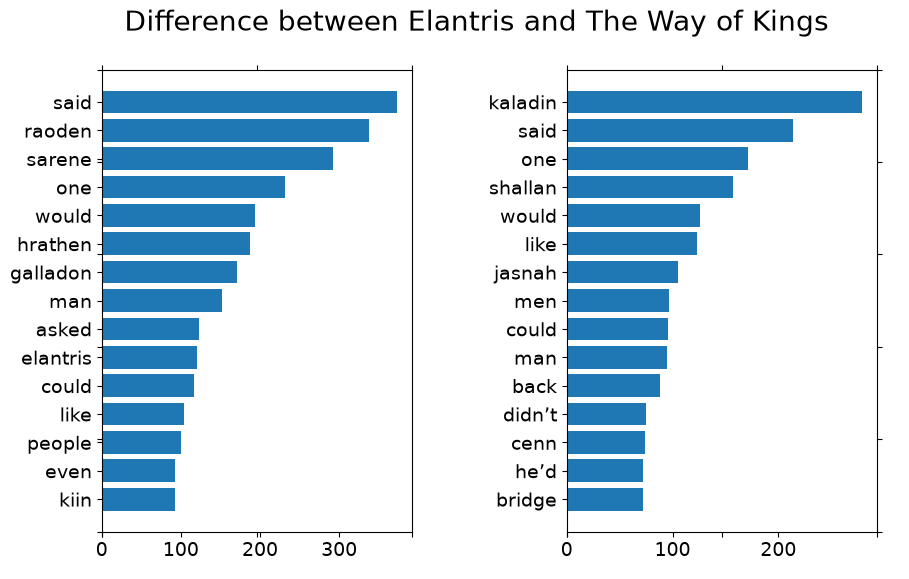

In [5]:
# Plotting Results:
import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline
def plotTwoLists (wf_el, wf_wok, title):
    f = plt.figure (figsize=(10, 6))
    f .suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax .spines ['top'] .set_color ('none')
    ax .spines ['bottom'] .set_color ('none')
    ax .spines ['left'] .set_color ('none')
    ax .spines ['right'] .set_color ('none')
    ax .tick_params (labelcolor='w', top='off', bottom='off', left='off', right='off', labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f .add_subplot (121)
    plt .subplots_adjust (wspace=.5)

    pos = np .arange (len(wf_el)) 
    ax1 .tick_params (axis='both', which='major', labelsize=14)
    pylab .yticks (pos, [ x [0] for x in wf_el])
    ax1 .barh (range(len(wf_el)), [ x [1] for x in wf_el], align='center')

    ax2 = f .add_subplot (122)
    ax2 .tick_params (axis='both', which='major', labelsize=14)
    pos = np .arange (len(wf_wok)) 
    pylab .yticks (pos, [ x [0] for x in wf_wok])
    ax2 .barh (range (len(wf_wok)), [ x [1] for x in wf_wok], align='center')

plotTwoLists (wf_el, wf_wok, 'Difference between Elantris and The Way of Kings')